# Рекомендательная система на Amazon Musical Instruments

## Загрузка необходимых библиотек

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')
import urllib.request
import gzip
import os
import json
import glob

# Настройка отображения графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print('Библиотеки загружены успешно!')

Библиотеки загружены успешно!


## Загрузка данных

In [16]:
# %% [markdown]
# ## 2. Загрузка данных

# %%
import gzip
import json
import os
import glob
from IPython.display import display

# Показываем текущую рабочую директорию
print(f"Текущая директория: {os.getcwd()}\n")

# Ищем файл Musical_Instruments_5.json.gz
filename = "Musical_Instruments_5.json.gz"
file_path = None

if os.path.exists(filename):
    file_path = filename
    print(f"✓ Файл найден в текущей директории")

else:
    print("Поиск файла...")
    found_files = glob.glob(f"**/{filename}", recursive=True)
    
    if found_files:
        file_path = found_files[0]
        print(f"Файл найден: {file_path}")
    else:
        possible_paths = [
            f"HW 31/{filename}",
            f"../HW 31/{filename}",
            f"../../HW 31/{filename}",
        ]
        
        for path in possible_paths:
            if os.path.exists(path):
                file_path = path
                print(f"Файл найден: {path}")
                break
    
    data_list = list(parse_json_gz(file_path))
    print(f"Загружено {len(data_list)} записей")
    
    # Создаём DataFrame
    df = pd.DataFrame(data_list)
    print(f"DataFrame создан. Размер: {df.shape}")
    print(f"Колонки: {df.columns.tolist()}")
    
    # Оставляем только нужные колонки
    needed_cols = ['reviewerID', 'asin', 'overall', 'unixReviewTime']
    available_cols = [col for col in needed_cols if col in df.columns]
    
    if available_cols:
        df = df[available_cols]
        print(f"Используем колонки: {available_cols}")

# Показываем первые строки (используем display для явного отображения)
display(df.head())

Текущая директория: /Users/zenyuk.k.s/Desktop/New Git/Otus_ML-Proffessional/HW 37

Поиск файла...
Файл найден: ../HW 31/Musical_Instruments_5.json.gz
Загружено 231392 записей
DataFrame создан. Размер: (231392, 12)
Колонки: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'style', 'image']
Используем колонки: ['reviewerID', 'asin', 'overall', 'unixReviewTime']


,reviewerID,asin,overall,unixReviewTime
0,A3FO5AKVTFRCRJ,0739079891,5.0,1477785600
1,A3UCGC1DHFMBCE,0739079891,5.0,1467244800
2,A2S9SLRYLPGYZB,0739079891,5.0,1462752000
3,A15RTJWPG8OKOE,0739079891,4.0,1460246400
4,A12ET1WO3OAVU7,0739079891,1.0,1454716800


## EDA

In [17]:
# Базовая информация о данных
print("=" * 60)
print("БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)
print(f"Всего отзывов: {len(df):,}")
print(f"Уникальных пользователей: {df['reviewerID'].nunique():,}")
print(f"Уникальных товаров: {df['asin'].nunique():,}")
print(f"Средний рейтинг: {df['overall'].mean():.2f}")
print(f"Диапазон дат: {df['unixReviewTime'].min()} - {df['unixReviewTime'].max()}")

# Разреженность
n_users = df['reviewerID'].nunique()
n_items = df['asin'].nunique()
sparsity = 1 - (len(df) / (n_users * n_items))
print(f"Разреженность матрицы: {sparsity:.2%}")

БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
Всего отзывов: 231,392
Уникальных пользователей: 27,530
Уникальных товаров: 10,620
Средний рейтинг: 4.47
Диапазон дат: 1067299200 - 1538092800
Разреженность матрицы: 99.92%


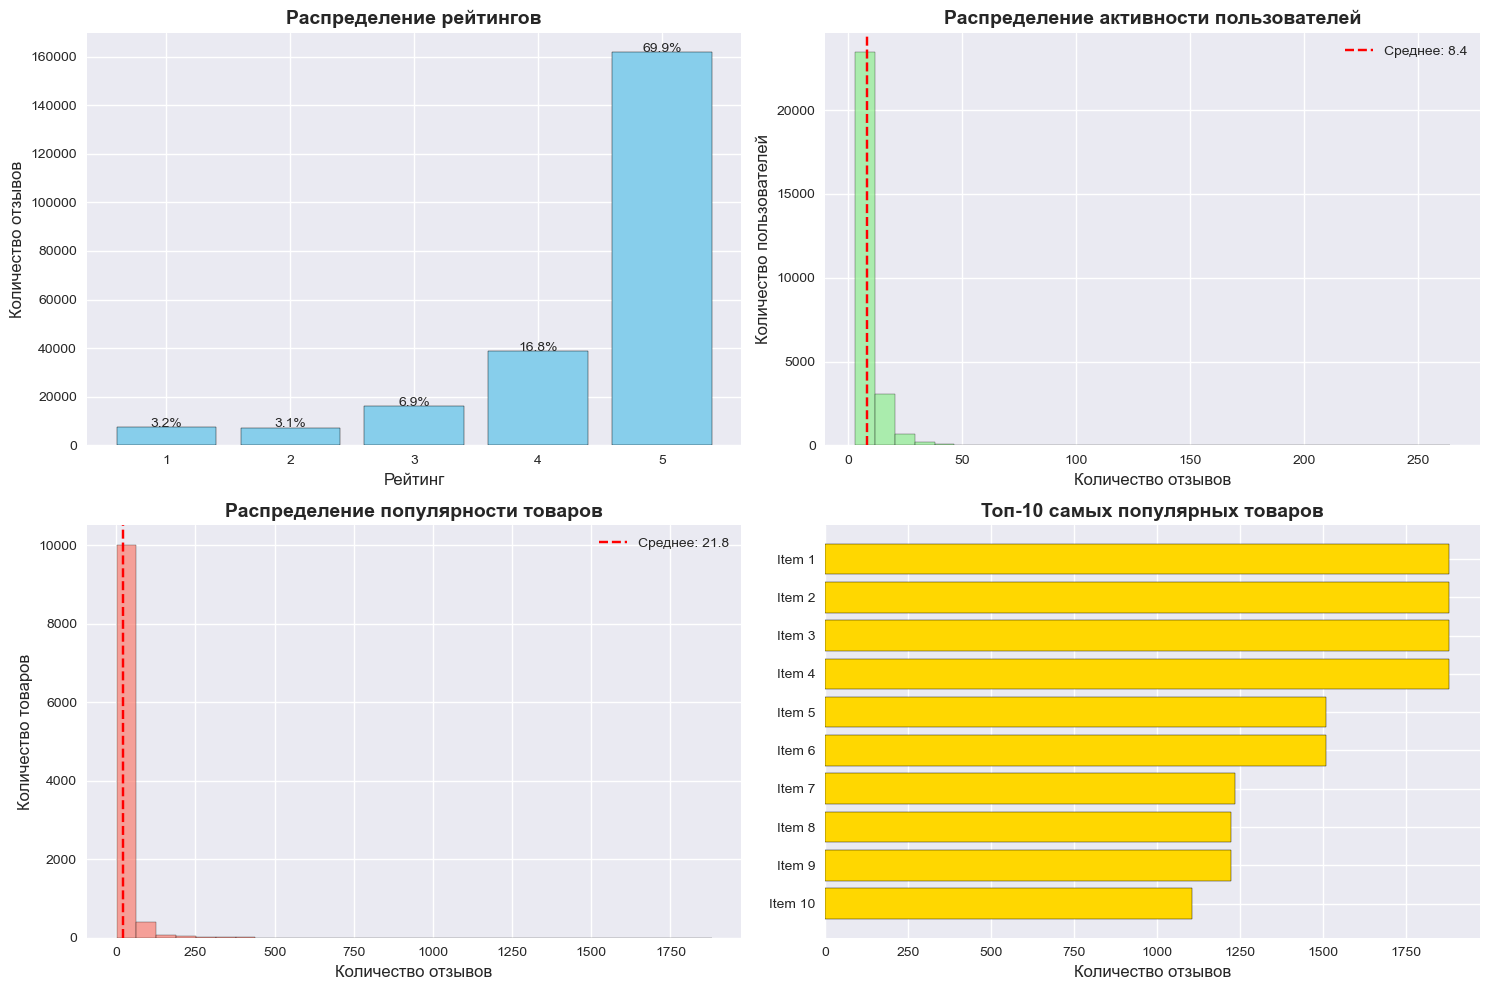


СТАТИСТИКА АКТИВНОСТИ

Активность пользователей:
  Среднее: 8.41
  Медиана: 6.0
  Мин: 3, Макс: 264

Популярность товаров:
  Среднее: 21.79
  Медиана: 9.0
  Мин: 1, Макс: 1880


In [18]:
# Распределение рейтингов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение рейтингов
rating_counts = df['overall'].value_counts().sort_index()
axes[0, 0].bar(rating_counts.index, rating_counts.values, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Рейтинг', fontsize=12)
axes[0, 0].set_ylabel('Количество отзывов', fontsize=12)
axes[0, 0].set_title('Распределение рейтингов', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks([1, 2, 3, 4, 5])

# Добавляем проценты на столбцы
for i, (rating, count) in enumerate(rating_counts.items()):
    percentage = count / len(df) * 100
    axes[0, 0].text(i + 1, count + 100, f'{percentage:.1f}%', ha='center', fontsize=10)

# 2. Активность пользователей
user_activity = df.groupby('reviewerID').size()
axes[0, 1].hist(user_activity, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Количество отзывов', fontsize=12)
axes[0, 1].set_ylabel('Количество пользователей', fontsize=12)
axes[0, 1].set_title('Распределение активности пользователей', fontsize=14, fontweight='bold')
axes[0, 1].axvline(user_activity.mean(), color='red', linestyle='--', label=f'Среднее: {user_activity.mean():.1f}')
axes[0, 1].legend()

# 3. Популярность товаров
item_popularity = df.groupby('asin').size()
axes[1, 0].hist(item_popularity, bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Количество отзывов', fontsize=12)
axes[1, 0].set_ylabel('Количество товаров', fontsize=12)
axes[1, 0].set_title('Распределение популярности товаров', fontsize=14, fontweight='bold')
axes[1, 0].axvline(item_popularity.mean(), color='red', linestyle='--', label=f'Среднее: {item_popularity.mean():.1f}')
axes[1, 0].legend()

# 4. Топ-10 самых популярных товаров
top_items = item_popularity.nlargest(10)
axes[1, 1].barh(range(len(top_items)), top_items.values, color='gold', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_items)))
axes[1, 1].set_yticklabels([f'Item {i+1}' for i in range(len(top_items))])
axes[1, 1].set_xlabel('Количество отзывов', fontsize=12)
axes[1, 1].set_title('Топ-10 самых популярных товаров', fontsize=14, fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Статистика
print("\n" + "=" * 60)
print("СТАТИСТИКА АКТИВНОСТИ")
print("=" * 60)
print(f"\nАктивность пользователей:")
print(f"  Среднее: {user_activity.mean():.2f}")
print(f"  Медиана: {user_activity.median():.1f}")
print(f"  Мин: {user_activity.min()}, Макс: {user_activity.max()}")
print(f"\nПопулярность товаров:")
print(f"  Среднее: {item_popularity.mean():.2f}")
print(f"  Медиана: {item_popularity.median():.1f}")
print(f"  Мин: {item_popularity.min()}, Макс: {item_popularity.max()}")

## 4. Предобработка данных и разбиение

In [19]:
# Кодируем пользователей и товары в индексы
user_ids = df['reviewerID'].unique()
item_ids = df['asin'].unique()

user2idx = {uid: idx for idx, uid in enumerate(user_ids)}
item2idx = {iid: idx for idx, iid in enumerate(item_ids)}
idx2item = {idx: iid for iid, idx in item2idx.items()}

df['user_idx'] = df['reviewerID'].map(user2idx)
df['item_idx'] = df['asin'].map(item2idx)

# Сортируем по времени для каждого пользователя
df = df.sort_values(['user_idx', 'unixReviewTime'])

print(f"Подготовка данных завершена")
print(f"Пользователей: {len(user2idx)}, Товаров: {len(item2idx)}")

Подготовка данных завершена
Пользователей: 27530, Товаров: 10620


In [20]:
# Leave-One-Out разбиение
train_data = []
test_data = []

for user_idx in df['user_idx'].unique():
    user_interactions = df[df['user_idx'] == user_idx]
    
    # Все кроме последнего - в train
    train_interactions = user_interactions.iloc[:-1]
    # Последний - в test
    test_interaction = user_interactions.iloc[-1]
    
    train_data.append(train_interactions)
    test_data.append(test_interaction)

train_df = pd.concat(train_data)
test_df = pd.DataFrame(test_data)

print(f"\nРазбиение Leave-One-Out:")
print(f"Train: {len(train_df)} взаимодействий")
print(f"Test: {len(test_df)} взаимодействий")
print(f"Проверка: {len(train_df) + len(test_df)} = {len(df)}")


Разбиение Leave-One-Out:
Train: 203862 взаимодействий
Test: 27530 взаимодействий
Проверка: 231392 = 231392


## 5. Построение рекомендательных моделей

### Модель 1: Popularity Baseline

Рекомендует самые популярные товары (по количеству отзывов в train set)

In [21]:
class PopularityRecommender:
    
    def __init__(self):
        self.item_popularity = None
        
    def fit(self, train_df):
        # Считаем популярность каждого товара
        self.item_popularity = train_df.groupby('item_idx').size().sort_values(ascending=False)
        
    def recommend(self, user_idx, train_user_items, top_n=10):
        recommendations = []
        for item_idx in self.item_popularity.index:
            if item_idx not in train_user_items:
                recommendations.append(item_idx)
            if len(recommendations) >= top_n:
                break
        return recommendations

print('Класс PopularityRecommender создан')

Класс PopularityRecommender создан


### Модель 2: Item-based Collaborative Filtering

Находит товары, похожие на те, с которыми пользователь уже взаимодействовал

In [22]:
class ItemBasedCF:
    """Item-based Collaborative Filtering"""
    
    def __init__(self):
        self.user_item_matrix = None
        self.item_similarity = None
        
    def fit(self, train_df, n_users, n_items):
        # Создаем матрицу пользователь-товар
        row = train_df['user_idx'].values
        col = train_df['item_idx'].values
        data = np.ones(len(train_df))
        
        self.user_item_matrix = csr_matrix((data, (row, col)), shape=(n_users, n_items))
        
        # Нормализуем матрицу (делим на норму пользователя)
        user_norms = np.array(self.user_item_matrix.sum(axis=1)).flatten()
        user_norms[user_norms == 0] = 1
        normalized_matrix = self.user_item_matrix.multiply(1.0 / user_norms[:, np.newaxis])
        
        # Считаем косинусное сходство между товарами
        self.item_similarity = cosine_similarity(normalized_matrix.T)
        
    def recommend(self, user_idx, train_user_items, top_n=10):
        """Рекомендует товары на основе сходства с уже просмотренными"""
        # Получаем оценки для всех товаров
        scores = np.zeros(self.user_item_matrix.shape[1])
        
        for item_idx in train_user_items:
            scores += self.item_similarity[item_idx]
        
        # Исключаем товары, с которыми пользователь уже взаимодействовал
        for item_idx in train_user_items:
            scores[item_idx] = -np.inf
            
        # Возвращаем top_n
        top_items = np.argsort(scores)[::-1][:top_n]
        return top_items.tolist()

print('Класс ItemBasedCF создан')

Класс ItemBasedCF создан


### Модель 3: User-based Collaborative Filtering

Находит похожих пользователей и рекомендует товары, которые понравились этим похожим пользователям

In [23]:
class UserBasedCF:
    """User-based Collaborative Filtering"""
    
    def __init__(self):
        self.user_item_matrix = None
        self.user_similarity = None
        
    def fit(self, train_df, n_users, n_items):
        # Создаем матрицу пользователь-товар
        row = train_df['user_idx'].values
        col = train_df['item_idx'].values
        data = np.ones(len(train_df))
        
        self.user_item_matrix = csr_matrix((data, (row, col)), shape=(n_users, n_items))
        
        # Считаем косинусное сходство между пользователями
        self.user_similarity = cosine_similarity(self.user_item_matrix)
        
    def recommend(self, user_idx, train_user_items, top_n=10):
        """Рекомендует товары на основе похожих пользователей"""
        # Находим похожих пользователей
        similar_users = np.argsort(self.user_similarity[user_idx])[::-1]
        
        # Собираем оценки
        scores = np.zeros(self.user_item_matrix.shape[1])
        
        for similar_user in similar_users[1:]:  # Пропускаем самого себя
            if self.user_similarity[user_idx, similar_user] > 0:
                # Получаем товары этого пользователя
                user_items = self.user_item_matrix[similar_user].toarray().flatten()
                scores += user_items * self.user_similarity[user_idx, similar_user]
        
        # Исключаем товары, с которыми пользователь уже взаимодействовал
        for item_idx in train_user_items:
            scores[item_idx] = -np.inf
            
        # Возвращаем top_n
        top_items = np.argsort(scores)[::-1][:top_n]
        return top_items.tolist()

print('Класс UserBasedCF создан')

Класс UserBasedCF создан


## 6. Обучение моделей

In [24]:
n_users = len(user2idx)
n_items = len(item2idx)

print("Обучение моделей...")

# Модель 1: Popularity Baseline
print("\n Обучение Popularity Baseline...")
pop_model = PopularityRecommender()
pop_model.fit(train_df)
print("   Popularity Baseline обучена")

# Модель 2: Item-based CF
print("\n Обучение Item-based CF...")
item_cf = ItemBasedCF()
item_cf.fit(train_df, n_users, n_items)
print("   Item-based CF обучена")

# Модель 3: User-based CF
print("\n Обучение User-based CF...")
user_cf = UserBasedCF()
user_cf.fit(train_df, n_users, n_items)
print("   User-based CF обучена")

print("\nВсе модели обучены!")

Обучение моделей...

 Обучение Popularity Baseline...
   Popularity Baseline обучена

 Обучение Item-based CF...
   Item-based CF обучена

 Обучение User-based CF...
   User-based CF обучена

Все модели обучены!


## 7. Оценка качества моделей

Оцениваем по метрикам:
- **HR@10 (Hit Rate)**: Доля случаев, когда тестовый товар попал в топ-10
- **MRR@10 (Mean Reciprocal Rank)**: Среднее значение 1/rank для тестового товара
- **NDCG@10 (Normalized DCG)**: Учитывает позицию товара в списке
- **Coverage**: Доля всех товаров, которые хоть раз были рекомендованы

In [25]:
def calculate_metrics(recommended_items, ground_truth_item):
    hr = 0.0
    mrr = 0.0
    ndcg = 0.0
    
    if ground_truth_item in recommended_items:
        hr = 1.0
        rank = recommended_items.index(ground_truth_item) + 1
        mrr = 1.0 / rank
        ndcg = 1.0 / np.log2(rank + 1)
    
    return hr, mrr, ndcg

def evaluate_model(model, test_df, train_df, model_type='popularity'):
    hrs = []
    mrrs = []
    ndcgs = []
    all_recommended_items = set()
    
    for idx, row in test_df.iterrows():
        user_idx = row['user_idx']
        ground_truth_item = row['item_idx']
        
        # Получаем товары, с которыми пользователь взаимодействовал в train
        train_user_items = set(train_df[train_df['user_idx'] == user_idx]['item_idx'].values)
        
        # Получаем рекомендации
        if model_type == 'popularity':
            recommended_items = model.recommend(user_idx, train_user_items, top_n=10)
        else:
            recommended_items = model.recommend(user_idx, train_user_items, top_n=10)
        
        # Считаем метрики
        hr, mrr, ndcg = calculate_metrics(recommended_items, ground_truth_item)
        hrs.append(hr)
        mrrs.append(mrr)
        ndcgs.append(ndcg)
        
        # Собираем все рекомендованные товары для coverage
        all_recommended_items.update(recommended_items)
    
    # Coverage - доля товаров, которые хоть раз были рекомендованы
    coverage = len(all_recommended_items) / n_items
    
    return {
        'HR@10': np.mean(hrs),
        'MRR@10': np.mean(mrrs),
        'NDCG@10': np.mean(ndcgs),
        'Coverage': coverage
    }

print('Функции для оценки созданы')

Функции для оценки созданы


In [26]:
# Оценка всех моделей
print("Оценка моделей на тестовой выборке...")
print("=" * 60)

results = {}

print("\n1. Оценка Popularity Baseline...")
results['Popularity Baseline'] = evaluate_model(pop_model, test_df, train_df, 'popularity')
print(f"   HR@10: {results['Popularity Baseline']['HR@10']:.4f}")
print(f"   MRR@10: {results['Popularity Baseline']['MRR@10']:.4f}")
print(f"   NDCG@10: {results['Popularity Baseline']['NDCG@10']:.4f}")
print(f"   Coverage: {results['Popularity Baseline']['Coverage']:.4f}")

print("\n2. Оценка Item-based CF...")
results['Item-based CF'] = evaluate_model(item_cf, test_df, train_df, 'item_cf')
print(f"   HR@10: {results['Item-based CF']['HR@10']:.4f}")
print(f"   MRR@10: {results['Item-based CF']['MRR@10']:.4f}")
print(f"   NDCG@10: {results['Item-based CF']['NDCG@10']:.4f}")
print(f"   Coverage: {results['Item-based CF']['Coverage']:.4f}")

print("\n3. Оценка User-based CF...")
results['User-based CF'] = evaluate_model(user_cf, test_df, train_df, 'user_cf')
print(f"   HR@10: {results['User-based CF']['HR@10']:.4f}")
print(f"   MRR@10: {results['User-based CF']['MRR@10']:.4f}")
print(f"   NDCG@10: {results['User-based CF']['NDCG@10']:.4f}")
print(f"   Coverage: {results['User-based CF']['Coverage']:.4f}")

print("\n" + "=" * 60)
print("Оценка завершена!")

Оценка моделей на тестовой выборке...

1. Оценка Popularity Baseline...
   HR@10: 0.0198
   MRR@10: 0.0114
   NDCG@10: 0.0133
   Coverage: 0.0022

2. Оценка Item-based CF...
   HR@10: 0.0696
   MRR@10: 0.0507
   NDCG@10: 0.0551
   Coverage: 0.9943

3. Оценка User-based CF...
   HR@10: 0.0733
   MRR@10: 0.0465
   NDCG@10: 0.0527
   Coverage: 0.3199

Оценка завершена!


## 8. Визуализация результатов

In [27]:
# Создание таблицы результатов
results_df = pd.DataFrame(results).T
results_df = results_df * 100  # Переводим в проценты для наглядности

print("\nРезультаты оценки моделей (%):")
print(results_df.round(2).to_string())


Результаты оценки моделей (%):
                     HR@10  MRR@10  NDCG@10  Coverage
Popularity Baseline   1.98    1.14     1.33      0.22
Item-based CF         6.96    5.07     5.51     99.43
User-based CF         7.33    4.65     5.27     31.99


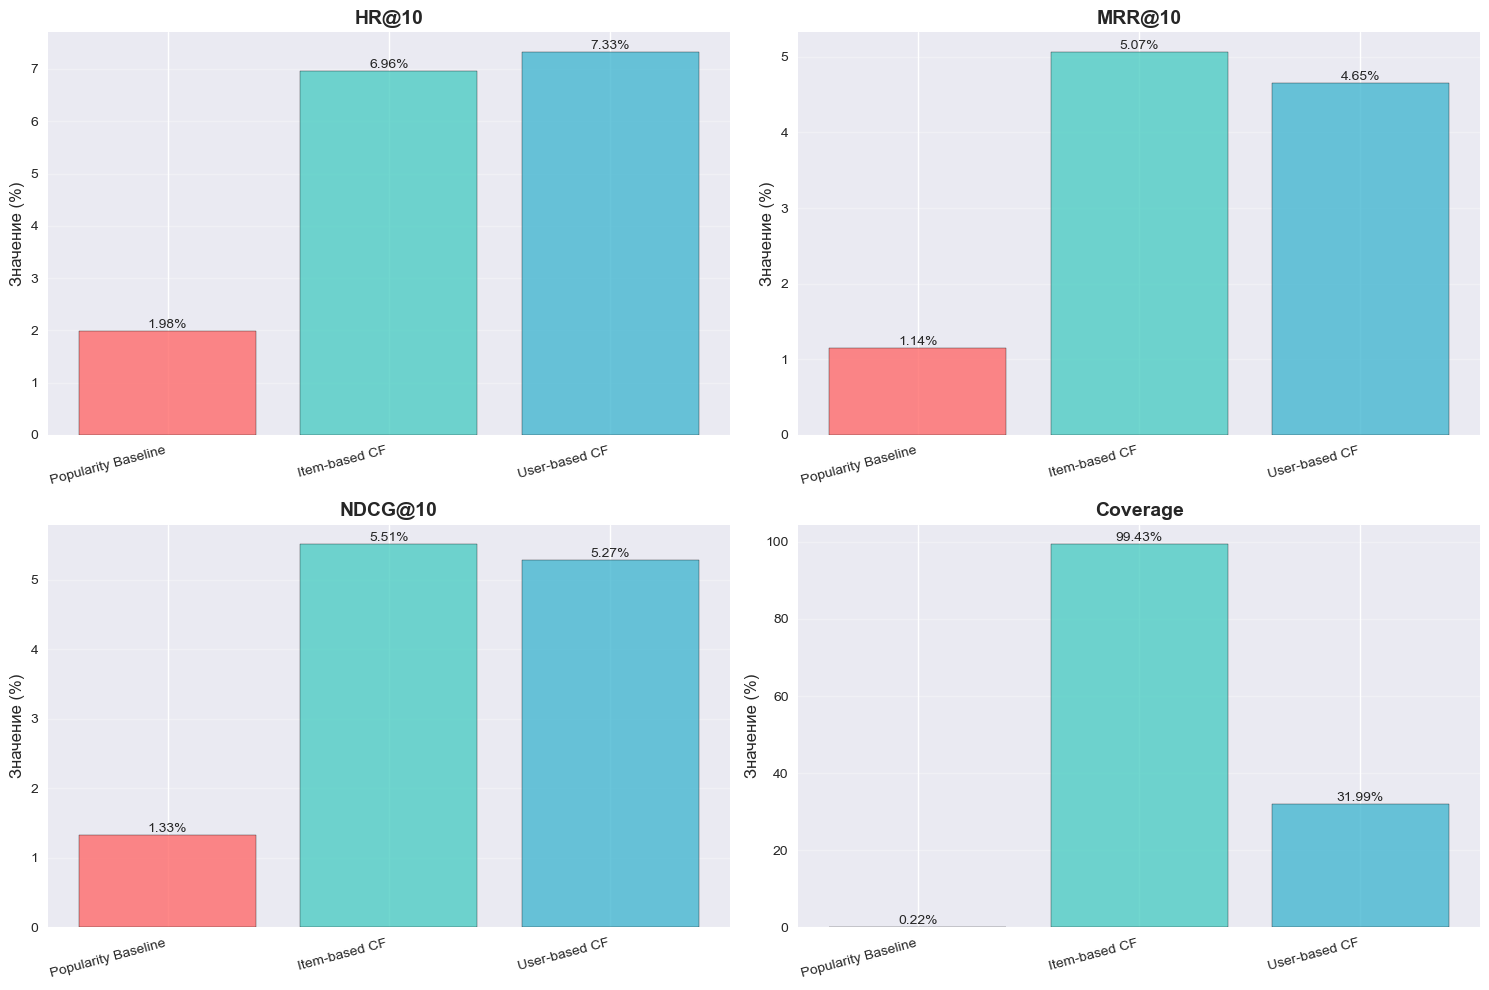

In [28]:
# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['HR@10', 'MRR@10', 'NDCG@10', 'Coverage']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    
    values = [results[model][metric] * 100 for model in results.keys()]
    bars = axes[row, col].bar(range(len(values)), values, color=colors, edgecolor='black', alpha=0.8)
    
    axes[row, col].set_xticks(range(len(values)))
    axes[row, col].set_xticklabels(results.keys(), rotation=15, ha='right')
    axes[row, col].set_ylabel('Значение (%)', fontsize=12)
    axes[row, col].set_title(metric, fontsize=14, fontweight='bold')
    axes[row, col].grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars, values):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                           f'{value:.2f}%',
                           ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Выводы

In [29]:
print("=" * 70)
print("ВЫВОДЫ")
print("=" * 70)

# Находим лучшую модель по HR@10
best_model = max(results.keys(), key=lambda x: results[x]['HR@10'])

print(f"\n Лучшая модель по HR@10: {best_model}")
print(f"  HR@10: {results[best_model]['HR@10']:.4f}")
print(f"  MRR@10: {results[best_model]['MRR@10']:.4f}")
print(f"  NDCG@10: {results[best_model]['NDCG@10']:.4f}")

print("\n Сравнение с бейзлайном:")
improvement_hr = (results[best_model]['HR@10'] - results['Popularity Baseline']['HR@10']) / results['Popularity Baseline']['HR@10'] * 100
improvement_mrr = (results[best_model]['MRR@10'] - results['Popularity Baseline']['MRR@10']) / results['Popularity Baseline']['MRR@10'] * 100
improvement_ndcg = (results[best_model]['NDCG@10'] - results['Popularity Baseline']['NDCG@10']) / results['Popularity Baseline']['NDCG@10'] * 100

print(f"  Улучшение HR@10: +{improvement_hr:.1f}%")
print(f"  Улучшение MRR@10: +{improvement_mrr:.1f}%")
print(f"  Улучшение NDCG@10: +{improvement_ndcg:.1f}%")

print("\n Анализ покрытия:")
print(f"  Popularity Baseline: {results['Popularity Baseline']['Coverage']*100:.2f}%")
print(f"  Item-based CF: {results['Item-based CF']['Coverage']*100:.2f}%")
print(f"  User-based CF: {results['User-based CF']['Coverage']*100:.2f}%")

ВЫВОДЫ

 Лучшая модель по HR@10: User-based CF
  HR@10: 0.0733
  MRR@10: 0.0465
  NDCG@10: 0.0527

 Сравнение с бейзлайном:
  Улучшение HR@10: +270.5%
  Улучшение MRR@10: +306.7%
  Улучшение NDCG@10: +296.9%

 Анализ покрытия:
  Popularity Baseline: 0.22%
  Item-based CF: 99.43%
  User-based CF: 31.99%
